# Zigzag Persistence Honeybee Project

Code tutorial for computing zigzag persistence diagrams on honeybee trophallaxis experiments.

---
## Functions for generating Point Clouds

In [ ]:
import numpy as np
import cv2
from PIL import Image
from skimage.filters import threshold_minimum
import os
import glob
import re

## Get bee locations from single frame
def desired_objects(bin_img):
    k = 115
    bee_size = 2900
    bee_locations = []

    num_regions, regions, stats, centroids = cv2.connectedComponentsWithStats(bin_img.astype(np.uint8), connectivity=4)
    sizes = stats[:, -1]

    for i in range(1, num_regions):
        if sizes[i] > 1000:
            num_bees = int(np.around(sizes[i] / bee_size))
            x_loc, y_loc = np.where(regions == i)
            for j in range(num_bees):
                idx = np.random.randint(x_loc.shape[0])
                bee_locations.append([x_loc[idx], y_loc[idx]])

    return np.array(bee_locations)

## iterate through image files and build point clouds
def extract_point_clouds(image_files):
    point_clouds = []
    kernel = np.ones((7, 7), np.uint8)

    for image_path in image_files:
        arr = Image.open(image_path)
        data_gray = np.asarray(arr.convert("L"))

        im_blur = cv2.GaussianBlur(src=data_gray, ksize=(5, 5), sigmaX=0)
        thresh_min = threshold_minimum(data_gray)
        binary_min = im_blur > thresh_min + 5
        binary_min_arr = np.array(binary_min, dtype=np.uint8)
        closing = cv2.morphologyEx(binary_min_arr, cv2.MORPH_CLOSE, kernel)
        data = 255 - closing * 255

        point_cloud = desired_objects(data)
        point_clouds.append(point_cloud)

    return point_clouds

## Get image file names from folder, in sorted order
def get_png_files_sorted_numerically(folder_path):
    numbers = re.compile(r'(\d+)')
    def numerical_sort(value):
        parts = numbers.split(value)
        parts[1::2] = map(int, parts[1::2])
        return parts
    png_files = sorted(glob.glob(os.path.join(folder_path, '*.png')), key=numerical_sort)
    return png_files

## write out point cloud data to a text file
def write_point_clouds_to_file(point_clouds, filename="point_clouds.txt"):
    with open(filename, 'w') as f:
        for i, pc in enumerate(point_clouds):
            f.write(f"Point Cloud {i}:\n")
            for point in pc:
                f.write(f"{point[0]} {point[1]}\n")
            f.write("\n")

def read_point_cloud_file(filename="point_clouds.txt"):
    point_clouds = []
    current_point_cloud = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("Point Cloud"):
                if current_point_cloud:
                    point_clouds.append(np.array(current_point_cloud))
                current_point_cloud = []
            elif line:  # Skip empty lines
                try:
                    x, y = map(float, line.split())
                    current_point_cloud.append([x, y])
                except ValueError:
                    print("Warning: Skipping invalid line")
        if current_point_cloud:
            point_clouds.append(np.array(current_point_cloud))
    return point_clouds

---
## Zigzag Persistence Functions

#### install dionysis package

In [ ]:
!pip install dionysus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 4.8 MB/s eta 0:00:00


### Working Zigzag Computation
- and plotting functions


In [ ]:
# Zigzag Persistence on Bee Swarm Point Clouds using Dionysus
# uses zigzag_homology_persistence() from Dionysus2

import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from skimage.filters import threshold_minimum
import dionysus as d
from tqdm import tqdm
import csv

## STEP 1: Extract Point Clouds from Bee Video Frames
def desired_objects(bin_img):
    bee_size = 2900
    bee_locations = []
    num_regions, regions, stats, centroids = cv2.connectedComponentsWithStats(bin_img.astype(np.uint8), connectivity=4)
    sizes = stats[:, -1]
    for i in range(1, num_regions):
        if sizes[i] > 1000:
            num_bees = int(np.around(sizes[i] / bee_size))
            x_loc, y_loc = np.where(regions == i)
            for j in range(num_bees):
                idx = np.random.randint(x_loc.shape[0])
                bee_locations.append([x_loc[idx], y_loc[idx]])
    return np.array(bee_locations)

def extract_point_clouds(image_files):
    point_clouds = []
    kernel = np.ones((7, 7), np.uint8)
    for image_path in tqdm(image_files, desc="Extracting point clouds"):
        arr = Image.open(image_path)
        data_gray = np.asarray(arr.convert("L"))
        im_blur = cv2.GaussianBlur(src=data_gray, ksize=(5, 5), sigmaX=0)
        thresh_val = threshold_minimum(im_blur)
        binary = (im_blur < thresh_val).astype(np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        binary = cv2.dilate(binary, kernel, iterations=2)
        bees = desired_objects(binary)
        point_clouds.append(bees)
    return point_clouds

## STEP 2: Build Simplices and Time Ranges
def construct_filtration_and_times(point_clouds, r=25.0, max_dim=1):
    all_simplices = []
    times = []
    vertex_offset = 0
    vertex_map = {}
    current_time = 0

    for i in tqdm(range(len(point_clouds)), desc="Constructing filtration"):
        pts = point_clouds[i]
        rips = d.fill_rips(pts, max_dim, r)

        for s in rips:
            vs = tuple(sorted(s))
            vs_global = tuple(v + vertex_offset for v in vs)
            if vs_global not in vertex_map:
                vertex_map[vs_global] = len(all_simplices)
                all_simplices.append(vs_global)
                times.append([])
            times[vertex_map[vs_global]].extend([current_time, current_time + 1])

        vertex_offset += len(pts)
        current_time += 2

    f = d.Filtration([list(s) for s in all_simplices])
    return f, times

## STEP 3: Run Zigzag Homology Persistence
def compute_zigzag_diagram(filtration, times):
    print("Running zigzag persistence...")
    with tqdm(total=1, desc="Computing diagrams") as pbar:
        zz, dgms, cells = d.zigzag_homology_persistence(filtration, times)
        pbar.update(1)
    return dgms

## STEP 4: Plot and Save Persistence Diagram
def plot_persistence_diagram(diagram, output_prefix="zigzag_diagram"):
    plt.figure(figsize=(6,6))
    max_val = 0
    for dim, dgm in enumerate(tqdm(diagram, desc="Plotting diagrams")):
        births, deaths = [], []
        with open(f"{output_prefix}_H{dim}.csv", 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(["birth", "death"])
            for p in dgm:
                if p.death != float('inf'):
                    births.append(p.birth)
                    deaths.append(p.death)
                    max_val = max(max_val, p.death)
                    writer.writerow([p.birth, p.death])
        plt.scatter(births, deaths, label=f"H{dim}", s=2)

    plt.plot([0, max_val], [0, max_val], 'k--')
    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title("Zigzag Persistence Diagram")
    plt.legend()
    plt.savefig(f"{output_prefix}.png", dpi=300)
    plt.show()


#### Run pipeline

In [ ]:
## If extracting from images:
# image_files= get_png_files_sorted_numerically("/content/bee_frames")
# pcs = extract_point_clouds(image_files)

## If loading saved point cloud data
path = "/content/"          # replace with path to saved point cloud data
fname = "C0074_point_clouds.txt"

pcs = read_point_cloud_file(path+fname)

print("Building filtration and time intervals...")
filtration, time_ranges = construct_filtration_and_times(pcs, r=200.0)

print("Computing zigzag persistence...")
diagrams = compute_zigzag_diagram(filtration, time_ranges)

print("Plotting persistence diagram...")
plot_persistence_diagram(diagrams)

Building filtration and time intervals...


Constructing filtration: 100%|██████████| 1440/1440 [01:45<00:00, 13.68it/s]


Computing zigzag persistence...
Running zigzag persistence...


Computing diagrams:   0%|          | 0/1 [00:00<?, ?it/s]

---
## Version 2
- include plotting Betti Curves

In [ ]:
# Version 2: with Diagram Plotting and Betti Curve tracking

import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from skimage.filters import threshold_minimum
import dionysus as d
from tqdm import tqdm
import csv

## STEP 1: Extract Point Clouds from Bee Video Frames
def desired_objects(bin_img):
    bee_size = 2900
    bee_locations = []
    num_regions, regions, stats, centroids = cv2.connectedComponentsWithStats(bin_img.astype(np.uint8), connectivity=4)
    sizes = stats[:, -1]
    for i in range(1, num_regions):
        if sizes[i] > 1000:
            num_bees = int(np.around(sizes[i] / bee_size))
            x_loc, y_loc = np.where(regions == i)
            for j in range(num_bees):
                idx = np.random.randint(x_loc.shape[0])
                bee_locations.append([x_loc[idx], y_loc[idx]])
    return np.array(bee_locations)

def extract_point_clouds(image_files):
    point_clouds = []
    kernel = np.ones((7, 7), np.uint8)
    for image_path in tqdm(image_files, desc="Extracting point clouds"):
        arr = Image.open(image_path)
        data_gray = np.asarray(arr.convert("L"))
        im_blur = cv2.GaussianBlur(src=data_gray, ksize=(5, 5), sigmaX=0)
        thresh_val = threshold_minimum(im_blur)
        binary = (im_blur < thresh_val).astype(np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        binary = cv2.dilate(binary, kernel, iterations=2)
        bees = desired_objects(binary)
        point_clouds.append(bees)
    return point_clouds

## STEP 2: Build Zigzag Sequence from Raw Points
def construct_zigzag_sequence(point_clouds):
    sequence = []
    for i in range(len(point_clouds)):
        if point_clouds[i].size == 0:
            continue
        sequence.append(point_clouds[i])
        if i < len(point_clouds) - 1 and point_clouds[i+1].size > 0:
            union = np.vstack((point_clouds[i], point_clouds[i+1]))
            sequence.append(union)
    return sequence

## STEP 3: Build Filtration and Run Zigzag Persistence
def build_filtration_and_run_zigzag(sequence, r=RIPS_RADIUS, max_dim=MAX_DIM):
    all_simplices = []
    times = []
    vertex_offset = 0
    vertex_map = {}
    current_time = 0

    for points in tqdm(sequence, desc=f"Filtration @ r={r}"):
        f = d.fill_rips(points, max_dim, r)
        for s in f:
            vs = tuple(sorted(s))
            vs_global = tuple(v + vertex_offset for v in vs)
            if vs_global not in vertex_map:
                vertex_map[vs_global] = len(all_simplices)
                all_simplices.append(vs_global)
                times.append([])
            times[vertex_map[vs_global]].extend([current_time, current_time + 1])
        vertex_offset += len(points)
        current_time += 1

    filtration = d.Filtration([list(s) for s in all_simplices])
    zz, dgms, _ = d.zigzag_homology_persistence(filtration, times)
    return dgms

## STEP 4: Plot Persistence Diagram
def plot_persistence_diagram(diagrams):
    plt.figure(figsize=(6,6))
    colors = ['blue', 'orange', 'green']
    for dim, dgm in enumerate(diagrams):
        births = [p.birth for p in dgm if p.death != float('inf')]
        deaths = [p.death for p in dgm if p.death != float('inf')]
        plt.scatter(births, deaths, label=f"H{dim}", color=colors[dim % len(colors)], s=10)
    max_val = max([max(deaths)] + [max(births)])
    plt.plot([0, max_val], [0, max_val], 'k--')
    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title("Zigzag Persistence Diagram")
    plt.legend()
    plt.savefig("zigzag_persistence_diagram.png", dpi=300)
    plt.show()

## STEP 5: Framewise Betti Curve
def plot_betti_curve(diagrams, max_time):
    betti_curves = {0: [0]*(max_time+1), 1: [0]*(max_time+1)}
    for dim in [0, 1]:
        if dim >= len(diagrams): continue
        for p in diagrams[dim]:
            birth = int(np.floor(p.birth))
            death = int(np.ceil(p.death)) if p.death != float('inf') else max_time
            for t in range(birth, min(death, max_time+1)):
                betti_curves[dim][t] += 1
    plt.figure(figsize=(10,4))
    for dim, curve in betti_curves.items():
        plt.plot(curve, label=f"β{dim}")
    plt.xlabel("Zigzag Time Step")
    plt.ylabel("Betti Number")
    plt.title("Framewise Betti Numbers")
    plt.legend()
    plt.savefig("framewise_betti_curves.png", dpi=300)
    plt.show()

## Parameters ##
RIPS_RADIUS = 30.0
MAX_DIM = 1


Filtration @ r=30.0: 100%|██████████| 3193/3193 [00:07<00:00, 420.19it/s]


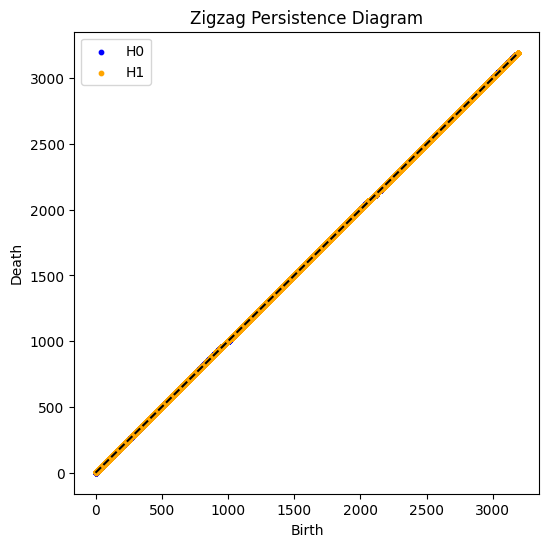

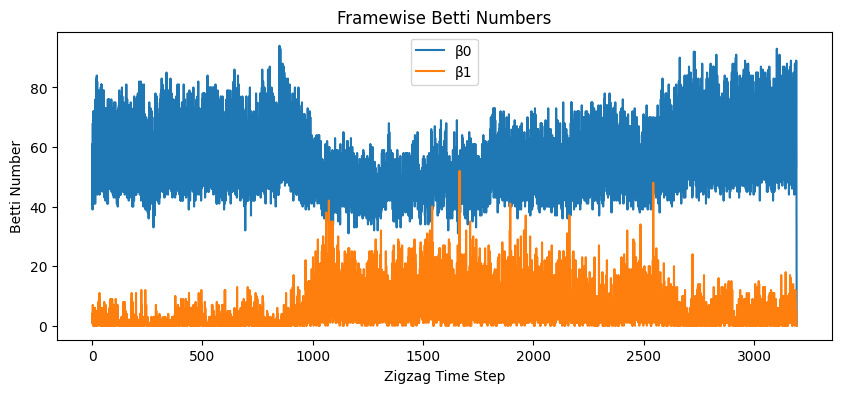

In [ ]:
## load from point cloud data
path = "/content/"
fname = "C0128_point_clouds.txt"
point_clouds = read_point_cloud_file(path+fname)

## load from images
# img_dir = "bee_frames"
# image_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.jpg')])

# point_clouds = extract_point_clouds(image_files)
zigzag_sequence = construct_zigzag_sequence(point_clouds)
diagrams = build_filtration_and_run_zigzag(zigzag_sequence)

if diagrams:
    plot_persistence_diagram(diagrams)
    plot_betti_curve(diagrams, max_time=len(zigzag_sequence))

---
## Betti Curve and CROCKER plots

In [ ]:
### Generate Betti curves and CROCKER plot code

## Betti Curve plots
def plot_betti_curve(diagrams, max_time):
    betti_curves = {0: [0]*(max_time+1), 1: [0]*(max_time+1)}
    for dim in [0, 1]:
        if dim >= len(diagrams): continue
        for p in diagrams[dim]:
            birth = int(np.floor(p.birth))
            death = int(np.ceil(p.death)) if p.death != float('inf') else max_time
            for t in range(birth, min(death, max_time+1)):
                betti_curves[dim][t] += 1
    plt.figure(figsize=(10,4))
    for dim, curve in betti_curves.items():
        plt.plot(curve, label=f"β{dim}")
    plt.xlabel("Zigzag Time Step")
    plt.ylabel("Betti Number")
    plt.title("Framewise Betti Numbers")
    plt.legend()
    plt.savefig("framewise_betti_curves.png", dpi=300)
    plt.show()

## CROCKER Plot! (Betti Surface over Time and Radius)
def crocker_plot(point_clouds, radii, max_dim=1):
    sequence = construct_zigzag_sequence(point_clouds)
    T = len(sequence)
    B = {0: np.zeros((len(radii), T)), 1: np.zeros((len(radii), T))}

    for i, r in enumerate(radii):
        dgms = build_filtration_and_run_zigzag(sequence, r, max_dim=max_dim)
        for dim in [0, 1]:
            if dim >= len(dgms): continue
            for p in dgms[dim]:
                birth = int(np.floor(p.birth))
                death = int(np.ceil(p.death)) if p.death != float('inf') else T
                for t in range(birth, min(death, T)):
                    B[dim][i, t] += 1

    for dim in [0, 1]:
        plt.figure(figsize=(10, 5))
        plt.imshow(B[dim], aspect='auto', origin='lower', cmap='inferno',
                   extent=[0, T, min(radii), max(radii)])
        plt.colorbar(label=f"β{dim}")
        plt.xlabel("Zigzag Time Step")
        plt.ylabel("Rips Radius")
        plt.title(f"CROCKER Plot (β{dim})")
        plt.savefig(f"crocker_beta{dim}.png", dpi=300)
        plt.show()


Filtration @ r=125.0: 100%|██████████| 3193/3193 [00:26<00:00, 122.29it/s]
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


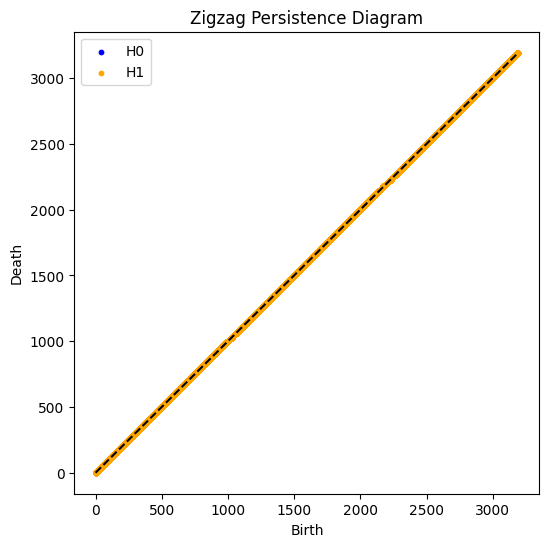

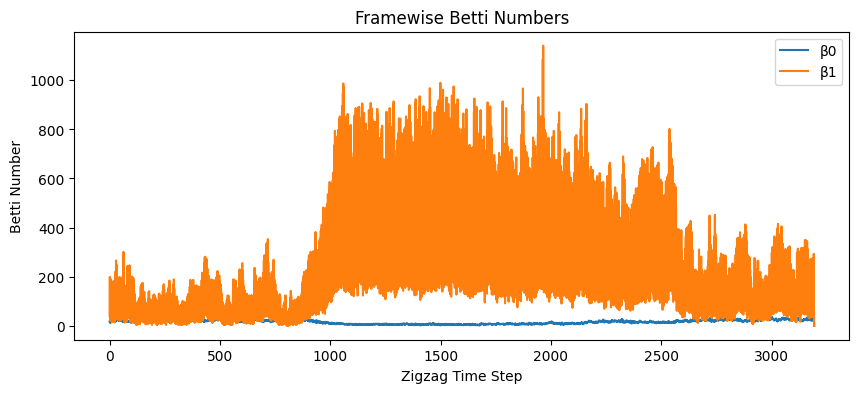

Filtration @ r=50: 100%|██████████| 3193/3193 [00:07<00:00, 420.03it/s]


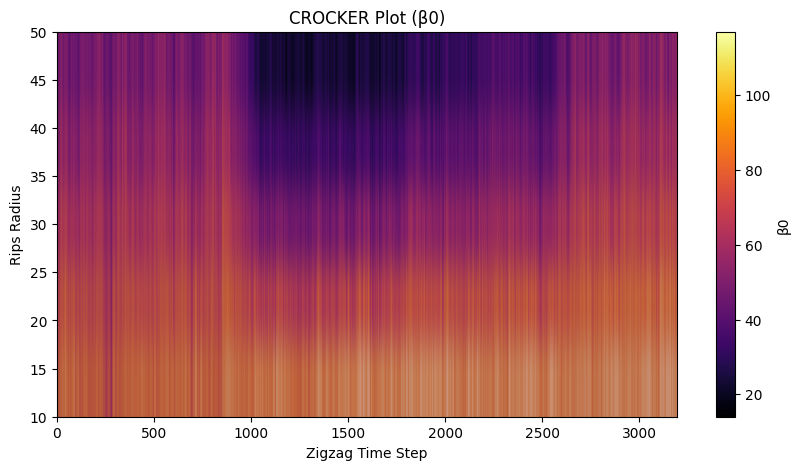

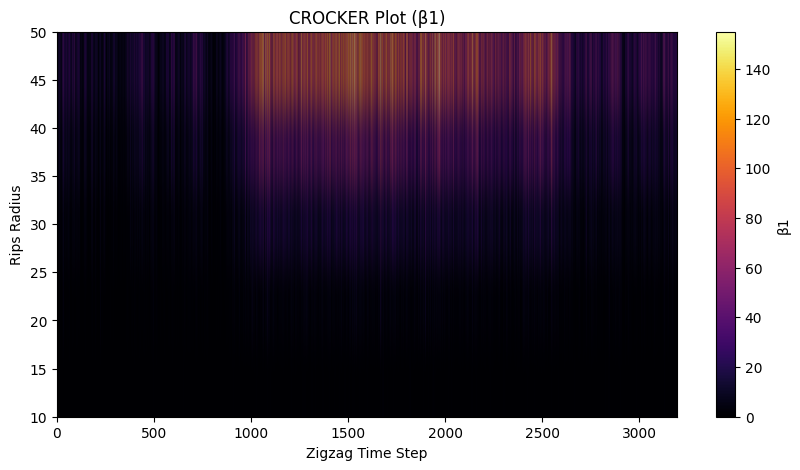

In [ ]:
path = "/content/"
fname = "C0128_point_clouds.txt"
point_clouds = read_point_cloud_file(path+fname)
sequence = construct_zigzag_sequence(point_clouds)

dgms = build_filtration_and_run_zigzag(sequence, r=125.0)
if dgms:
    plot_persistence_diagram(dgms)
    plot_betti_curve(dgms, max_time=len(sequence))
    crocker_plot(point_clouds, RIPS_RADII, max_dim=1)

---
### [WIP] Generate synthetic data for testing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dionysus as d
from tqdm import tqdm

## synthetic data gen
def generate_synthetic_frames(num_frames=10, grid_size=1000, num_clusters=3, points_per_cluster=10, jitter=30):
    np.random.seed(42)
    frames = []
    centers = np.random.rand(num_clusters, 2) * grid_size
    for t in range(num_frames):
        frame_points = []
        for cx, cy in centers:
            pts = np.random.randn(points_per_cluster, 2) * jitter + np.array([cx, cy])
            frame_points.append(pts)
        frames.append(np.vstack(frame_points))
    return frames

##
def construct_zigzag_sequence(frames):
    sequence = []
    for i in range(len(frames)):
        sequence.append(frames[i])
        if i < len(frames) - 1:
            sequence.append(np.vstack((frames[i], frames[i+1])))
    return sequence

## filter
def compute_zigzag(frames, r=100.0, max_dim=0):
    sequence = construct_zigzag_sequence(frames)
    all_simplices = []
    times = []
    vertex_offset = 0
    vertex_map = {}
    current_time = 0

    for pts in tqdm(sequence, desc="Building filtration"):
        f = d.fill_rips(pts, max_dim, r)
        for s in f:
            vs = tuple(sorted(s))
            vs_global = tuple(v + vertex_offset for v in vs)
            if vs_global not in vertex_map:
                vertex_map[vs_global] = len(all_simplices)
                all_simplices.append(vs_global)
                times.append([])
            times[vertex_map[vs_global]].extend([current_time, current_time + 1])
        vertex_offset += len(pts)
        current_time += 1

    filt = d.Filtration([list(s) for s in all_simplices])
    zz, dgms, _ = d.zigzag_homology_persistence(filt, times)
    return dgms, sequence

## Visualize persisent comps
def visualize_component(frames, diagram, dim=0, min_persistence=3):
    longest = [p for p in diagram[dim] if p.death != float('inf') and (p.death - p.birth) >= min_persistence]
    if not longest:
        print("No persistent components found.")
        return

    p = sorted(longest, key=lambda x: x.death - x.birth, reverse=True)[0]
    birth, death = int(p.birth), int(p.death)

    fig, axes = plt.subplots(1, death - birth + 1, figsize=(4 * (death - birth + 1), 4))
    for i, t in enumerate(range(birth, death + 1)):
        pts = frames[t]
        axes[i].scatter(pts[:, 0], pts[:, 1], s=5, color='black')
        axes[i].set_title(f"t = {t}")
        axes[i].set_xlim(0, 1000)
        axes[i].set_ylim(0, 1000)
    plt.tight_layout()
    plt.savefig("persistent_component_visualization.png", dpi=300)
    plt.show()

In [ ]:
synthetic_frames = generate_synthetic_frames(num_frames=10)
diagrams, sequence = compute_zigzag(synthetic_frames, r=100.0)
visualize_component(sequence, diagrams, dim=0, min_persistence=2)

Building filtration: 100%|██████████| 19/19 [00:00<00:00, 1304.60it/s]

No persistent components found.


In [ ]:
## do the pipeline
frames = generate_synthetic_frames(num_frames=20)
diagrams, seq = compute_zigzag(frames, r=400.0)
visualize_component(seq, diagrams, dim=0, min_persistence=2)

Building filtration: 100%|██████████| 39/39 [00:00<00:00, 839.15it/s]

1
No persistent components found.
